## **Modelos com Implementação Própria, NumPy**

**Tarefa 2 do Trabalho Prático — Aprendizagem Profunda**

1. **Stratified K-Fold (K=5)** — Comparação robusta de modelos
2. **Baseline — Regressão Logística Multi-Classe** (Softmax Regression)
3. **DNN — Deep Neural Network** com várias arquiteturas e regularização
4. **Retreino do melhor modelo** e avaliação final no dataset do professor

### **1. Imports e Carregamento dos Dados**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os, time

sys.path.append(os.path.abspath('../src'))

from neuralnet import NeuralNetwork
from layers import DenseLayer, DropoutLayer
from activations import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy
from optimizer import Adam, SGD
from logisticregression import LogisticRegression
from utils import (prepare_text_data, prepare_fold_data, transform_new_texts,
                    stratified_k_fold)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

### **2. Carregamento dos Dados**

In [2]:
print("A carregar os datasets...")

# Dataset principal (para K-Fold CV)
df_main = pd.read_csv('../data/dataset.csv', sep=';')
df_main.columns = df_main.columns.str.lower()
textos = df_main['text'].tolist()
labels = df_main['label'].tolist()

# Dataset de teste (125 textos do professor)
df_test = pd.read_csv('../data/dataset-test.csv', sep=';')
df_test.columns = df_test.columns.str.lower()
textos_test = df_test['text'].tolist()
labels_test = df_test['label'].tolist()

print(f"  Dataset principal: {len(textos)} textos")
print(f"  Dataset teste: {len(textos_test)} textos")
print(f"  Classes: {sorted(set(labels))}")

A carregar os datasets...
  Dataset principal: 122835 textos
  Dataset teste: 225 textos
  Classes: ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']


### **3. Validação Cruzada — Stratified K-Fold (K=5)**

Cada modelo é avaliado com 5-Fold CV estratificado. Em cada fold:
- TF-IDF é ajustado **apenas** nos dados de treino do fold (sem data leakage)
- O modelo treina e é avaliado no fold de validação
- Reportamos **média ± desvio padrão** da accuracy nos 5 folds

In [3]:
K = 3  # K=3 para 122k textos (K=5 demoraria horas em NumPy puro)
FEAT_PARAMS = dict(max_features=3000, char_features=2000, ngram_range=(1, 2), stop_words=set())
# Com 122k textos: 3000 word + 2000 char + 13 style = 5013 features (~5 GB RAM)

def kfold_baseline(textos, labels, k=K, lr_rate=0.05, l2=0.001, epochs=100):
    """K-Fold CV para a Regressão Logística baseline."""
    accs = []
    for fold, (train_idx, val_idx) in enumerate(stratified_k_fold(labels, n_splits=k)):
        texts_tr = [textos[i] for i in train_idx]
        texts_vl = [textos[i] for i in val_idx]
        labels_tr = [labels[i] for i in train_idx]
        labels_vl = [labels[i] for i in val_idx]

        X_tr, Y_tr, X_vl, Y_vl, _, enc = prepare_fold_data(
            texts_tr, labels_tr, texts_vl, labels_vl, **FEAT_PARAMS)

        np.random.seed(42)
        model = LogisticRegression(X_tr.shape[1], Y_tr.shape[1], lr_rate, l2)
        model.fit(X_tr, Y_tr, epochs=epochs, batch_size=64, verbose=False, patience=None)
        _, acc = model.evaluate(X_vl, Y_vl)
        accs.append(acc)
        print(f"  Fold {fold+1}: {acc:.2%}")
    return np.array(accs)

def kfold_dnn(textos, labels, camadas_config, k=K, epochs=100, batch_size=256,
              patience=15, lr=0.0001):
    """K-Fold CV para uma DNN."""
    accs = []
    for fold, (train_idx, val_idx) in enumerate(stratified_k_fold(labels, n_splits=k)):
        texts_tr = [textos[i] for i in train_idx]
        texts_vl = [textos[i] for i in val_idx]
        labels_tr = [labels[i] for i in train_idx]
        labels_vl = [labels[i] for i in val_idx]

        X_tr, Y_tr, X_vl, Y_vl, _, enc = prepare_fold_data(
            texts_tr, labels_tr, texts_vl, labels_vl, **FEAT_PARAMS)

        np.random.seed(42)
        adam = Adam(learning_rate=lr)
        nn = NeuralNetwork(loss_func=CategoricalCrossEntropy())
        prev = X_tr.shape[1]
        for n_units, dropout, l2 in camadas_config:
            nn.add(DenseLayer(prev, n_units, optimizer=adam, l2_lambda=l2))
            nn.add(ReLUActivation())
            if dropout > 0: nn.add(DropoutLayer(rate=dropout))
            prev = n_units
        nn.add(DenseLayer(prev, Y_tr.shape[1], optimizer=adam))
        nn.add(SoftmaxActivation())

        nn.fit(X_tr, Y_tr, epochs=epochs, batch_size=batch_size,
               verbose=False, X_val=X_vl, Y_val=Y_vl, patience=patience)
        _, acc = nn.evaluate(X_vl, Y_vl)
        accs.append(acc)
        print(f"  Fold {fold+1}: {acc:.2%}")
    return np.array(accs)

print("Funções de K-Fold definidas.")

Funções de K-Fold definidas.


### **3.1 Resultados do K-Fold**

In [4]:
cv_results = {}

# Baseline LR
print("\nBaseline LR:")
accs = kfold_baseline(textos, labels)
cv_results["Baseline LR"] = accs
print(f"  → Média: {accs.mean():.2%} ± {accs.std():.2%}")

# DNN configs
dnn_configs = {
    "DNN Wide (256→128)":    [(256, 0.3, 0.0), (128, 0.3, 0.0)],
    "DNN Narrow (128→64)":   [(128, 0.3, 0.0), (64, 0.3, 0.0)],
    "DNN Flat (128→128)":    [(128, 0.3, 0.0), (128, 0.3, 0.0)],
    "DNN Dropout (256→128)": [(256, 0.5, 0.0), (128, 0.5, 0.0)],
    "DNN D+L2 (256→128)":   [(256, 0.5, 0.01), (128, 0.5, 0.01)],
}

for nome, config in dnn_configs.items():
    print(f"\n{nome}:")
    accs = kfold_dnn(textos, labels, config)
    cv_results[nome] = accs
    print(f"  → Média: {accs.mean():.2%} ± {accs.std():.2%}")


Baseline LR:
  Fold 1: 90.58%
  Fold 2: 90.42%
  Fold 3: 90.70%
  → Média: 90.57% ± 0.12%

DNN Wide (256→128):
  Fold 1: 94.65%
  Fold 2: 94.46%
  Fold 3: 94.55%
  → Média: 94.55% ± 0.08%

DNN Narrow (128→64):
  Fold 1: 94.49%
  Fold 2: 94.46%
  Fold 3: 94.51%
  → Média: 94.49% ± 0.02%

DNN Flat (128→128):
  Fold 1: 94.68%
  Fold 2: 94.47%
  Fold 3: 94.48%
  → Média: 94.54% ± 0.10%

DNN Dropout (256→128):
  Fold 1: 94.69%
  Fold 2: 94.54%
  Fold 3: 94.54%
  → Média: 94.59% ± 0.07%

DNN D+L2 (256→128):
  Fold 1: 93.90%
  Fold 2: 93.86%
  Fold 3: 93.89%
  → Média: 93.88% ± 0.02%


In [5]:
# Tabela resumo do K-Fold
rows = []
for nome, accs in cv_results.items():
    rows.append({"Modelo": nome, "Média": f"{accs.mean():.2%}",
                 "Std": f"±{accs.std():.2%}",
                 "Min": f"{accs.min():.2%}", "Max": f"{accs.max():.2%}"})

df_cv = pd.DataFrame(rows).sort_values('Média', ascending=False)
print("Resumo do K-Fold Cross-Validation:")
print(df_cv.to_string(index=False))

Resumo do K-Fold Cross-Validation:
               Modelo  Média    Std    Min    Max
DNN Dropout (256→128) 94.59% ±0.07% 94.54% 94.69%
   DNN Wide (256→128) 94.55% ±0.08% 94.46% 94.65%
   DNN Flat (128→128) 94.54% ±0.10% 94.47% 94.68%
  DNN Narrow (128→64) 94.49% ±0.02% 94.46% 94.51%
   DNN D+L2 (256→128) 93.88% ±0.02% 93.86% 93.90%
          Baseline LR 90.57% ±0.12% 90.42% 90.70%


### **4. Retreino do Melhor Modelo + Avaliação no Teste**

Com base nos resultados do K-Fold, retreinamos o melhor modelo com
um split 80/20 (para early stopping) e avaliamos no dataset do professor.

In [6]:
# Retreinar com split 80/20 para ter early stopping
print("A preparar dados para retreino...")
X_train, Y_train, X_val, Y_val, transformers, encoder = prepare_text_data(
    textos, labels,
    max_features=3000, char_features=2000, val_size=0.20,
    use_stratify=True, ngram_range=(1, 2), stop_words=set()
)

X_test = transform_new_texts(textos_test, transformers)
Y_test = encoder.transform(np.array(labels_test))

input_dim = X_train.shape[1]
output_dim = Y_train.shape[1]
class_names = encoder.classes

print(f"  Treino: {X_train.shape} | Val: {X_val.shape} | Teste: {X_test.shape}")

# Selecionar a melhor config do K-Fold
melhor_nome = df_cv.iloc[0]['Modelo']
print(f"\nMelhor modelo pelo K-Fold: {melhor_nome}")

# Baseline?
if melhor_nome == "Baseline LR":
    np.random.seed(42)
    lr_model = LogisticRegression(input_dim, output_dim, 0.05, 0.001)
    t0 = time.time()
    lr_model.fit(X_train, Y_train, epochs=100, batch_size=256, verbose=True,
                 X_val=X_val, Y_val=Y_val, patience=15)
    tempo = time.time() - t0
    train_loss, train_acc = lr_model.evaluate(X_train, Y_train)
    val_loss, val_acc = lr_model.evaluate(X_val, Y_val)
    test_loss, test_acc = lr_model.evaluate(X_test, Y_test)
    melhor_modelo_obj = lr_model
    melhor_tipo = 'Baseline LR'
else:
    # Encontrar config correspondente
    config = dnn_configs[melhor_nome]
    np.random.seed(42)
    adam = Adam(learning_rate=0.0001)
    nn_model = NeuralNetwork(loss_func=CategoricalCrossEntropy())
    prev = input_dim
    for n_units, dropout, l2 in config:
        nn_model.add(DenseLayer(prev, n_units, optimizer=adam, l2_lambda=l2))
        nn_model.add(ReLUActivation())
        if dropout > 0: nn_model.add(DropoutLayer(rate=dropout))
        prev = n_units
    nn_model.add(DenseLayer(prev, output_dim, optimizer=adam))
    nn_model.add(SoftmaxActivation())

    t0 = time.time()
    nn_model.fit(X_train, Y_train, epochs=150, batch_size=256, verbose=True,
                 X_val=X_val, Y_val=Y_val, patience=15)
    tempo = time.time() - t0
    train_loss, train_acc = nn_model.evaluate(X_train, Y_train)
    val_loss, val_acc = nn_model.evaluate(X_val, Y_val)
    test_loss, test_acc = nn_model.evaluate(X_test, Y_test)
    melhor_modelo_obj = nn_model
    melhor_tipo = melhor_nome

print(f"\n🏆 Resultados finais — {melhor_tipo}:")
print(f"  Treino    — Acc: {train_acc:.2%}")
print(f"  Validação — Acc: {val_acc:.2%}")
print(f"  Teste     — Acc: {test_acc:.2%}")
print(f"  Tempo: {tempo:.1f}s")

A preparar dados para retreino...
  Treino: (98270, 5013) | Val: (24565, 5013) | Teste: (225, 5013)

Melhor modelo pelo K-Fold: DNN Dropout (256→128)
Epoch 1/150 | Loss: 0.6170 | Val Loss: 0.6195 | Train Acc: 81.27% | Val Acc: 81.42%
Epoch 11/150 | Loss: 0.1015 | Val Loss: 0.1530 | Train Acc: 96.68% | Val Acc: 94.53%
Epoch 21/150 | Loss: 0.0475 | Val Loss: 0.1482 | Train Acc: 98.70% | Val Acc: 94.94%
Epoch 31/150 | Loss: 0.0161 | Val Loss: 0.1624 | Train Acc: 99.76% | Val Acc: 95.05%

Early Stopping na epoca 31! Val Loss nao melhorou ha 15 epocas.
Melhor Val Loss: 0.1458
Melhores pesos restaurados.

🏆 Resultados finais — DNN Dropout (256→128):
  Treino    — Acc: 97.87%
  Validação — Acc: 94.86%
  Teste     — Acc: 75.11%
  Tempo: 828.2s


### **5. Avaliação Final**

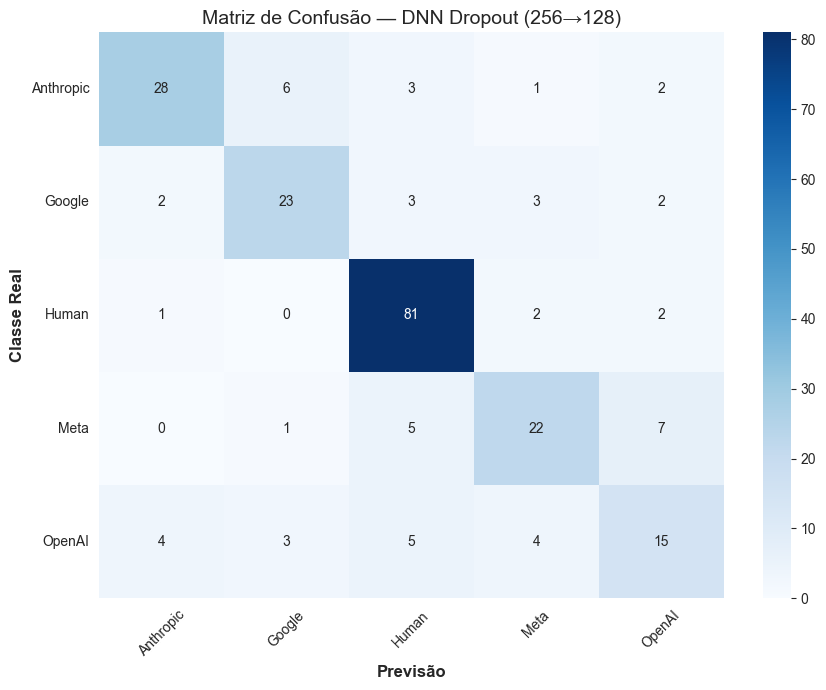


Classification Report — DNN Dropout (256→128):
              precision    recall  f1-score   support

   Anthropic       0.80      0.70      0.75        40
      Google       0.70      0.70      0.70        33
       Human       0.84      0.94      0.89        86
        Meta       0.69      0.63      0.66        35
      OpenAI       0.54      0.48      0.51        31

    accuracy                           0.75       225
   macro avg       0.71      0.69      0.70       225
weighted avg       0.74      0.75      0.75       225



In [7]:
from sklearn.metrics import confusion_matrix, classification_report

if melhor_tipo == 'Baseline LR':
    y_pred_test = melhor_modelo_obj.predict(X_test)
else:
    melhor_modelo_obj.set_training(False)
    y_pred_test = np.argmax(melhor_modelo_obj.predict(X_test), axis=1)
y_true_test = np.argmax(Y_test, axis=1)

cm = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão', fontsize=12, fontweight='bold')
plt.ylabel('Classe Real', fontsize=12, fontweight='bold')
plt.title(f'Matriz de Confusão — {melhor_tipo}', fontsize=14)
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

print(f"\nClassification Report — {melhor_tipo}:")
print(classification_report(y_true_test, y_pred_test, target_names=class_names, zero_division=0))

### **6. Guardar o Modelo**

In [8]:
import pickle

modelo_para_guardar = {
    'modelo_tipo': melhor_tipo,
    'transformers': transformers,
    'encoder': encoder,
    'class_names': class_names,
}

if melhor_tipo == 'Baseline LR':
    modelo_para_guardar['weights'] = melhor_modelo_obj.weights
    modelo_para_guardar['biases'] = melhor_modelo_obj.biases
else:
    pesos = []
    for layer in melhor_modelo_obj.layers:
        if hasattr(layer, 'get_weights'):
            pesos.append(layer.get_weights())
        else:
            pesos.append(None)
    modelo_para_guardar['pesos_camadas'] = pesos

caminho = '../models/numpy.pkl'
os.makedirs('../models', exist_ok=True)
with open(caminho, 'wb') as f:
    pickle.dump(modelo_para_guardar, f)
print(f"✅ Modelo guardado em '{caminho}'")

✅ Modelo guardado em '../models/numpy.pkl'
